# QuickBite Express - Crisis Recovery Analysis

## Notebook 4: Extra Insights

This notebook covers additional analysis beyond the primary questions 
to strengthen the recovery recommendations.

1. Behavior Shift Analysis - Did customers shift to lower value orders during crisis
2. Feedback and Delivery Outage Alignment - Do negative review spikes align with outage
3. Restaurant Churn Analysis - Which restaurants became inactive after the crisis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = "../data/"

orders      = pd.read_csv(BASE_PATH + "fact_orders.csv")
ratings     = pd.read_csv(BASE_PATH + "fact_ratings.csv")
restaurants = pd.read_csv(BASE_PATH + "dim_restaurant.csv")
customers   = pd.read_csv(BASE_PATH + "dim_customer.csv")

orders['order_timestamp']   = pd.to_datetime(orders['order_timestamp'])
orders['is_cancelled_bool'] = orders['is_cancelled'] == 'Y'
orders['month']             = orders['order_timestamp'].dt.to_period('M')

def assign_phase(ts):
    if ts < pd.Timestamp('2025-06-01'):
        return 'Pre-Crisis'
    elif ts < pd.Timestamp('2025-08-01'):
        return 'Crisis'
    else:
        return 'Recovery'

orders['phase'] = orders['order_timestamp'].apply(assign_phase)
ratings         = ratings.dropna()

print("Data loaded and prepared")

Data loaded and prepared


## Analysis 1: Customer Behavior Shift

Investigating whether customers shifted from high-value orders 
to lower-value orders during the crisis, or whether the revenue 
loss was driven purely by order volume decline.

In [2]:
orders_clean = orders[orders['is_cancelled_bool'] == False]

behavior = orders_clean.groupby(['month', 'phase']).agg(
    total_orders    = ('order_id', 'count'),
    avg_order_value = ('total_amount', 'mean'),
    avg_discount    = ('discount_amount', 'mean'),
    avg_delivery_fee = ('delivery_fee', 'mean')
).reset_index()

behavior['avg_order_value']  = behavior['avg_order_value'].round(2)
behavior['avg_discount']     = behavior['avg_discount'].round(2)
behavior['avg_delivery_fee'] = behavior['avg_delivery_fee'].round(2)
behavior['month_str']        = behavior['month'].astype(str)

print(behavior[['month_str', 'phase', 'total_orders', 
                 'avg_order_value', 'avg_discount']].to_string(index=False))

month_str      phase  total_orders  avg_order_value  avg_discount
  2025-01 Pre-Crisis         22076           352.16         20.62
  2025-02 Pre-Crisis         21272           351.16         20.49
  2025-03 Pre-Crisis         22133           352.53         20.30
  2025-04 Pre-Crisis         20210           352.65         20.44
  2025-05 Pre-Crisis         21221           350.93         20.57
  2025-06     Crisis          8219           351.36         20.50
  2025-07     Crisis          7768           350.75         20.14
  2025-08   Recovery          7485           353.09         20.31
  2025-09   Recovery          7670           350.04         19.64


### Chart: Average Order Value by Month

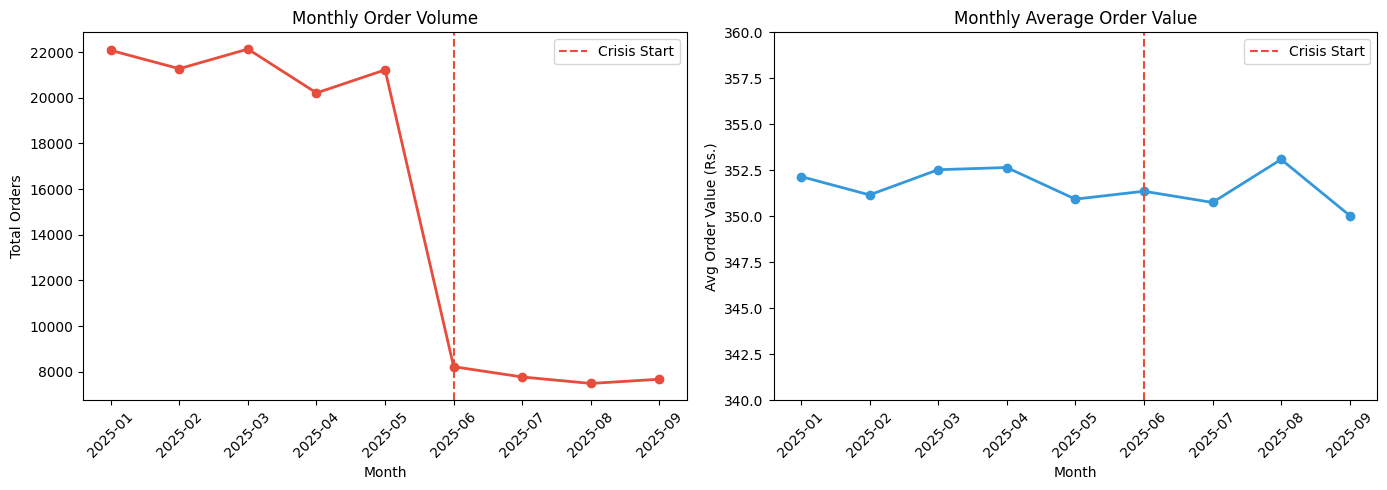

In [3]:
import os
os.makedirs('../assets', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(behavior['month_str'], behavior['total_orders'], 
         color='#e74c3c', linewidth=2, marker='o')
ax1.set_title('Monthly Order Volume')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Orders')
ax1.tick_params(axis='x', rotation=45)
ax1.axvline(x='2025-06', color='#e74c3c', linestyle='--', linewidth=1.5, label='Crisis Start')
ax1.legend()

ax2.plot(behavior['month_str'], behavior['avg_order_value'], 
         color='#3498db', linewidth=2, marker='o')
ax2.set_title('Monthly Average Order Value')
ax2.set_xlabel('Month')
ax2.set_ylabel('Avg Order Value (Rs.)')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(340, 360)
ax2.axvline(x='2025-06', color='#e74c3c', linestyle='--', linewidth=1.5, label='Crisis Start')
ax2.legend()

plt.tight_layout()
plt.savefig('../assets/extra1_behavior_shift.png', dpi=150)
plt.show()

### Observation

Average order value remained stable between Rs. 350 and Rs. 353 
across all nine months, showing no significant change during 
the crisis or recovery period.

This confirms that the revenue loss was driven entirely by 
the decline in order volume and not by customers placing 
smaller or cheaper orders.

Customers who continued using the platform maintained their 
spending behavior, which is a positive signal. It suggests 
that price sensitivity was not a factor and that the crisis 
impacted customer trust rather than willingness to spend.

Recovery strategy should therefore focus on bringing back 
lost customers rather than introducing discounts or 
lower price points, as the existing customers are willing 
to spend at the same level as before.

## Analysis 2: Negative Review Spike Alignment

Checking whether the spike in negative reviews aligns 
with the delivery outage period in June 2025.

In [4]:
ratings['review_timestamp'] = pd.to_datetime(ratings['review_timestamp'],
                                              format='mixed', dayfirst=True)
ratings['month'] = ratings['review_timestamp'].dt.to_period('M')

monthly_sentiment = ratings.groupby('month').agg(
    avg_sentiment    = ('sentiment_score', 'mean'),
    negative_reviews = ('sentiment_score', lambda x: (x < 0).sum()),
    total_reviews    = ('sentiment_score', 'count')
).reset_index()

monthly_sentiment['negative_pct']  = (monthly_sentiment['negative_reviews'] / 
                                       monthly_sentiment['total_reviews'] * 100).round(2)
monthly_sentiment['avg_sentiment'] = monthly_sentiment['avg_sentiment'].round(3)
monthly_sentiment['month_str']     = monthly_sentiment['month'].astype(str)

print(monthly_sentiment[['month_str', 'avg_sentiment', 
                          'negative_reviews', 'total_reviews', 
                          'negative_pct']].to_string(index=False))

month_str  avg_sentiment  negative_reviews  total_reviews  negative_pct
  2025-01          0.788                 0          10939          0.00
  2025-02          0.700                 0          10588          0.00
  2025-03          0.869                 0          10971          0.00
  2025-04          0.649                 2          10141          0.02
  2025-05          0.744                 0          10605          0.00
  2025-06         -0.187              2980           4165         71.55
  2025-07         -0.155              2573           3880         66.31
  2025-08         -0.299              2997           3668         81.71
  2025-09         -0.347              3341           3868         86.38


### Chart: Negative Review Spike

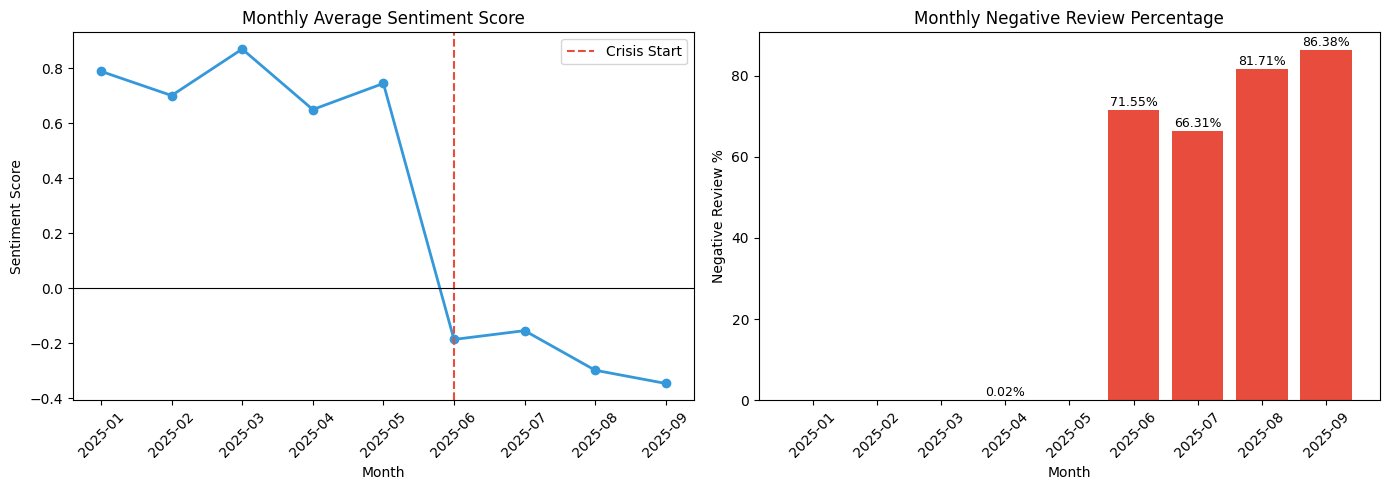

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(monthly_sentiment['month_str'], monthly_sentiment['avg_sentiment'],
         color='#3498db', linewidth=2, marker='o')
ax1.set_title('Monthly Average Sentiment Score')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sentiment Score')
ax1.tick_params(axis='x', rotation=45)
ax1.axvline(x='2025-06', color='#e74c3c', linestyle='--', linewidth=1.5, label='Crisis Start')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.legend()

ax2.bar(monthly_sentiment['month_str'], monthly_sentiment['negative_pct'],
        color=['#2ecc71' if s >= 0 else '#e74c3c' for s in monthly_sentiment['avg_sentiment']])
ax2.set_title('Monthly Negative Review Percentage')
ax2.set_xlabel('Month')
ax2.set_ylabel('Negative Review %')
ax2.tick_params(axis='x', rotation=45)

for i, val in enumerate(monthly_sentiment['negative_pct']):
    if val > 0:
        ax2.text(i, val + 1, f'{val}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/extra2_sentiment_spike.png', dpi=150)
plt.show()

### Observation

Negative reviews were virtually non-existent during the pre-crisis 
period with 0% negative sentiment from January to May 2025.

In June 2025, negative reviews spiked to 71.55% of all reviews, 
directly coinciding with the food safety incident and delivery outage. 
This confirms that the crisis was the sole trigger for customer dissatisfaction.

The situation worsened through the recovery phase with negative 
review percentage rising to 86.38% in September 2025. 
This means that 86 out of every 100 reviews in September 
were negative, indicating that customer trust has continued 
to erode even after the crisis period ended.

Average sentiment score dropped from a positive 0.74 in May 2025 
to a negative 0.35 in September 2025, crossing the zero line 
in June 2025 and never recovering since.

This trend suggests that the recovery measures taken so far 
have not been effective in rebuilding customer trust and 
that more aggressive intervention is needed.

## Analysis 3: Restaurant Churn Pattern

Identifying which restaurants became inactive after the crisis 
and whether any patterns exist in terms of partner type 
or cuisine category.

In [6]:
# restaurants active in pre-crisis
pre_crisis_restaurants = set(
    orders[orders['phase'] == 'Pre-Crisis']['restaurant_id'].unique()
)

# restaurants active in recovery
recovery_restaurants = set(
    orders[orders['phase'] == 'Recovery']['restaurant_id'].unique()
)

# restaurants that were active pre-crisis but not in recovery
churned_restaurants = pre_crisis_restaurants - recovery_restaurants

print("Restaurants active in pre-crisis  :", len(pre_crisis_restaurants))
print("Restaurants active in recovery    :", len(recovery_restaurants))
print("Restaurants churned after crisis  :", len(churned_restaurants))

# get details of churned restaurants
churned_rest_details = restaurants[restaurants['restaurant_id'].isin(churned_restaurants)]

print("\nChurned Restaurants by Partner Type")
print(churned_rest_details['partner_type'].value_counts().to_string())

print("\nChurned Restaurants by Cuisine Type")
print(churned_rest_details['cuisine_type'].value_counts().head(8).to_string())

print("\nChurned Restaurants by Active Status")
print(churned_rest_details['is_active'].value_counts().to_string())

Restaurants active in pre-crisis  : 19919
Restaurants active in recovery    : 11524
Restaurants churned after crisis  : 8442

Churned Restaurants by Partner Type
partner_type
Restaurant       5906
Cloud Kitchen    2536

Churned Restaurants by Cuisine Type
cuisine_type
North Indian    1669
South Indian    1293
Chinese         1266
Biryani         1207
Pizza           1054
Fast Food        835
Desserts         711
Healthy          407

Churned Restaurants by Active Status
is_active
Y    7608
N     834


### Chart: Restaurant Churn Pattern

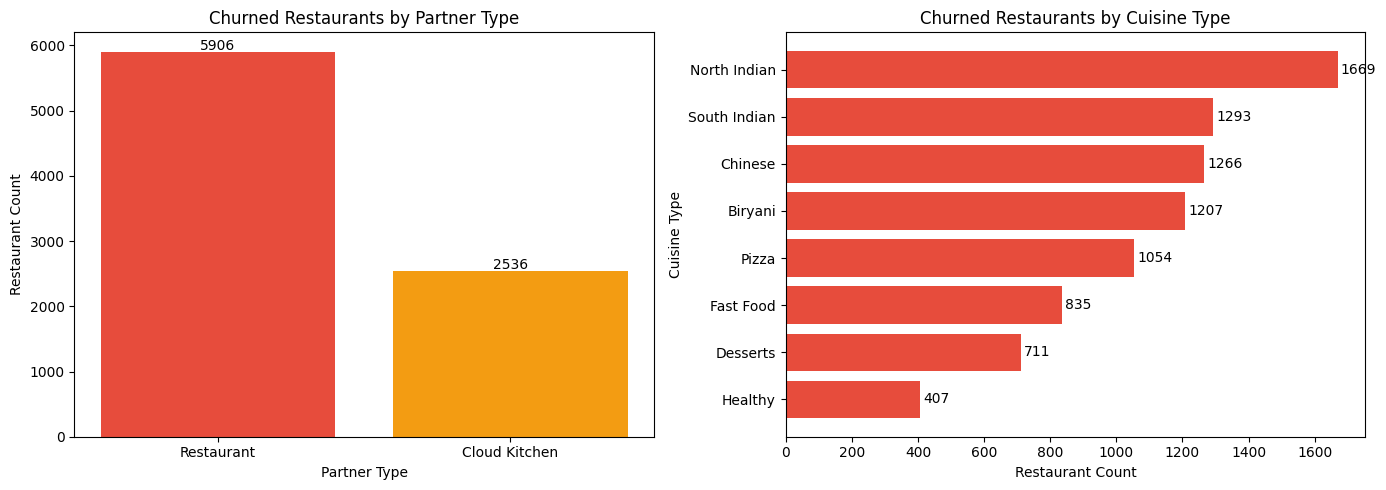

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

partner_counts = churned_rest_details['partner_type'].value_counts()
ax1.bar(partner_counts.index, partner_counts.values, color=['#e74c3c', '#f39c12'])
ax1.set_title('Churned Restaurants by Partner Type')
ax1.set_xlabel('Partner Type')
ax1.set_ylabel('Restaurant Count')

for i, val in enumerate(partner_counts.values):
    ax1.text(i, val + 30, str(val), ha='center')

cuisine_counts = churned_rest_details['cuisine_type'].value_counts().head(8)
ax2.barh(cuisine_counts.index, cuisine_counts.values, color='#e74c3c')
ax2.set_title('Churned Restaurants by Cuisine Type')
ax2.set_xlabel('Restaurant Count')
ax2.set_ylabel('Cuisine Type')
ax2.invert_yaxis()

for i, val in enumerate(cuisine_counts.values):
    ax2.text(val + 10, i, str(val), va='center')

plt.tight_layout()
plt.savefig('../assets/extra3_restaurant_churn.png', dpi=150)
plt.show()

### Observation

8,442 restaurants that were active during the pre-crisis period 
did not place any orders in the recovery phase, representing 
a 42.4% restaurant churn rate.

By partner type, standalone restaurants account for 5,906 churned 
partners while cloud kitchens account for 2,536. Standalone 
restaurants were more likely to shift to competing platforms 
as they have less dependency on a single delivery partner.

North Indian, South Indian, and Chinese cuisines have the highest 
churn counts, which aligns with the finding from Q10 that these 
are also the most preferred cuisines among high value customers. 
Losing restaurants in these categories directly impacts the ability 
to retain and recover high value customers.

Notably, 7,608 of the churned restaurants still show as active 
in the system, meaning they have not been formally deactivated 
but simply stopped receiving orders. This suggests they may have 
shifted to competitor platforms rather than closing down entirely, 
making them potential targets for re-engagement campaigns.

## Extra Insights Summary

Analysis 1 confirmed that average order value remained stable 
at Rs. 350 to Rs. 353 throughout all nine months. The revenue 
loss was driven entirely by order volume decline and not by 
customers placing smaller orders.

Analysis 2 showed that negative reviews spiked from 0% in 
pre-crisis to 71.55% in June 2025, directly aligning with 
the delivery outage and food safety incident. By September 2025, 
86.38% of all reviews were negative, indicating that customer 
trust has not been rebuilt despite recovery efforts.

Analysis 3 revealed that 8,442 restaurants churned after the 
crisis, representing a 42.4% restaurant churn rate. Standalone 
restaurants churned more than cloud kitchens. North Indian, 
South Indian, and Chinese cuisine restaurants were most affected, 
which directly impacts the ability to serve high value customers 
who prefer these cuisines.